**Important**: This Notebook requires GPU access on Google Colab.

# Fine Tuning of Open-Source Models Using PEFT/LORA

## Problem Statement and Business Case - Project Overview  
- In Previous projects, we used pre-trained LLMs off-the-shelf models. Now, let's dive into fine-tuning pre-trained LLM to perform exceptionally well on a specific task and dataset.
- LLM fine-tuning refers to the process of adapting a pre-trained LLM to perfrom a specific task or address a particular domain using a smaller, task specific dataset.
- Fine-Tuning adjusts the model's weights to better align it with the desireed outcomes for the new use case, leveraging the general knowledge the model already acquired during its initial training.

### LLM Fine-Tuning Examples  
- A Healthcare company fine-tunes a pre-trained model on medical resports and patient notes, enabbling it to generate accurate, coherent patient reports tailored for healthcare professionals.
    - Joint-pain, Sun sensitivity, skin rahs -> **`Base LLM`** -> Allergy
    - Joint-Pain, Sun sensitivity, Skin rash? -> **`Fine-Tuned LLM`** -> Could be luus erythematosus, an autoimmune disease. You should visit a rheumatologist.

## Learning Objectives.  
- Learn when and why to fine-tune pre-trained models to adapt them to specific tasks or specialized domains.
- Understand how parameter-efficient fine-tuning methods like `LoRA` amke it possible to adapt large models using limited hardware, such as Colab GPUs.
- Use tools like Hugging Face's and `SFTTrainer` to fine-tune transformer models for supervised learning taks such as classification.
- Prepare datasets in the correct format for Hugging Face Fine-tuning pipelines.
- Evaluate model performance by calculating accuracy, precision, recall, and F1-score using the scikit-learn library.

## Import Key Libraries and Datasets.  
We'll perform financial news sentiment classification using the `Daniel-Ml/sentiment-analysis-for-financial-news-v2` dataset, which contains financial news labeled as `positive`, `negative` or `neutral`.  
**What We'll Build & Compare**  
A system to classify Financial news, comparing two different approaches:
1. **Zero-Shot Open Source**: Using a pre-trained, small open-source model (like Gemma-1B) without any fine-tuning.
2. **Fine-Tuned Open Source**: Fine-tuning the same open-source model on this dataset with colab using efficient techniques (PEFT/LoRA)  
**Tech Stack (The Tools We'll Use):**
- **Python & Google Colab (With GPU):** Our environment.
- **Hugging Face:** `transformers`, `datasets`, `accelerate`, `bitsandbytes`: For OS models and data.  
- **Hugging Face `peft`:**PEFT (Parameter-Efficient Fine-Tuning) is a library for efficiently adapting large pretrained models to various downstream applications without fine-tuning all of a model's parameters because it is prohibitively costly. https://huggingface.co/docs/peft/en/index
- **Hugging Face `trl`:** TRL (Transformer Reinforcement Learning) is a full stack library where we provide a set of tools to train transformer language models with methods like Supervised Fine-Tuning (SFT). https://huggingface.co/docs/trl/en/index
- **`scikit-learn`:** For calculating evaluation metrics.
- **`torch`:** The underlying deep learning framework.

In [2]:
print("Installing necessary Libraries for fine-tuning and evaluations....")

!pip install -q transformers accelerate torch datasets peft trl openai scikit-learn gradio
# %pip install -q transformers accelerate torch datasets peft trl openai scikit-learn gradio
print("Libraries installed successfully...")

Installing necessary Libraries for fine-tuning and evaluations....
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.1 MB/s eta 0:00:00
Libraries installed successfully...


In [1]:
import os
from huggingface_hub import login, notebook_login
notebook_login()
print("HF Login Successful (or login already present.)")

HF Login Successful (or login already present.)


In [2]:
import torch
import transformers
from transformers import(
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    BitsAndBytesConfig
)
from datasets import load_dataset, Dataset, DatasetDict
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import json
import time
from IPython.display import display, Markdown
import random

print("Core Libraries imported.")



Core Libraries imported.


In [3]:
# Check for the GPU avialability (Crucial for fine-tuning job)
if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name()}")
else:
    print("No GPU detected. Fine Tuning requires GPU. Please enable GPU in Runtime settings.")

GPU detected: Tesla T4


In [4]:
# Helper function for markdown library
def print_markdown(text):
    display(Markdown(text))

## Load and Prepare The Financial News Datasets.  
We'll load the `Daniel-ML/sentiment-analysis-for-financial-news-v2` dataset from te Hugging Face Hub. This dataset contains sentences from Financial News, with sentiments tagged.  
**Steps**:
1. Load the dataset using `load_dataset`.
2. Inspect its structure and labels.
3. Split the data into training and testing sets to evaluate our models fairly.  

Link to the dataset on Hugging Face: https://huggingface.co/datasets/Daniel-ML/sentiment-analysis-for-financial-news-v2/viewer

In [5]:
dataset_id = "Daniel-ML/sentiment-analysis-for-financial-news-v2"

print(f"Loading datset: {dataset_id}...")
labeled_dataset = load_dataset(dataset_id, split = 'train') # Load the main split
print("Dataset Loaded Successfully!")

# Let's view the dataset
print("\n--- Dataset Information --- \n {labeled_dataset}")

Loading datset: Daniel-ML/sentiment-analysis-for-financial-news-v2...
Dataset Loaded Successfully!

--- Dataset Information --- 
 {labeled_dataset}


In [6]:
# Let's view the datset features
print("\n--- Dataset Features --- \n{labeled_dataset.features}")


--- Dataset Features --- 
{labeled_dataset.features}


In [7]:
# Let's explore how many unique labels exist in the dataset
labels = labeled_dataset.to_pandas()['sentiment'].unique().tolist()
print(f"Unique labels in the datset : {labels}")

Unique labels in the datset : ['neutral', 'negative', 'positive']


In [8]:
# Let's view the data as a Pandas DataFrame
display(labeled_dataset.select(range(5)).to_pandas()[['text', 'sentiment']])

,text,sentiment
0,"According to Gran , the company has no plans t...",neutral
1,Technopolis plans to develop in stages an area...,neutral
2,The international electronic industry company ...,negative
3,With the new production plant the company woul...,positive
4,According to the company 's updated strategy f...,positive


In [9]:
# Let's Split the Data into Train and Test Sets ---
print("\nSplitting data into Train (90%) and Test (10%)...")
train_test_split_ratio = 0.10
seed = 42       # for reproducibility.

# Using datasets built-in method.
split_dataset = labeled_dataset.train_test_split(
    test_size = train_test_split_ratio,
    seed = seed,
    shuffle = True,
)

train_dataset = split_dataset['train']
test_dataset = split_dataset['test']

print(f"Training set size : {len(train_dataset)}")
print(f"Test set size : {len(test_dataset)}")
print("\nTrain/Test Split Complete")


Splitting data into Train (90%) and Test (10%)...
Training set size : 4361
Test set size : 485

Train/Test Split Complete


## Format The Data Into Supervised Fine Tuning (SFT) Trainer Format

In [10]:
# Let's define a function that performs chat messages formatting.
# We will use "apply_chat_template()" which wraps the messages in a format the model understands.
# Just like giving it a movie script so it knows who's speaking and when to repl.
# It takes a list of messages (like a chat between a user and an assistant.) and turns it into one long, properly formatted text, exactly how the model expect to read it.

def format_for_sft_gemma(example, tokenizer):
    # Define the conversation structure
    system_prompt = "Classify the sentiment of the following sentences from News as positive, negative, or neutral"
    user_prompt = f"Senetences: {example['text']}"
    assistant_response = example['sentiment']   # The Target label

    messages = [{
        'role' : 'user',
        'content' : f"{system_prompt} \n {user_prompt}"
    },
    {
        'role' : 'assistant',
        'content' : assistant_response
    },
    ]
    # Apply the tokenizer's chat template
    # tokenize = False: means we want the text output, not token IDs.
    # add_generation_prompt = False: means we're NOT addind the assistant prompt to generate the response. We already provided the assistant's message
    formatted_text = tokenizer.apply_chat_template(messages, tokenize = False, add_generation_prompt = False)
    return {"text": formatted_text}

print("\nSupervised Fine Tuning (SFT) Trainer formatting function defined.")


Supervised Fine Tuning (SFT) Trainer formatting function defined.


In [11]:
# !pip install -U bitsandbytes>=0.46.1
from tqdm.notebook import tqdm
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Let's choose the Gemma 3.1B Instruct Model by Google.
# It's a small instruction-tuned LLM that's good for chat, Q&A, etc.
os_model_id = 'google/gemma-3-1b-it'

# Let's define the quantization configuration.
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,                  # Use 4-bit weights (saves lots of RAM)
    bnb_4bit_quant_type = "nf4",        # nf4 is a better 4-bit format (Non-Float 4)
    bnb_4bit_compute_dtype = torch.float16  # Math is done in float16 for speed
)

# Let's load the Tokenizer associated with the model. Tokenizers convert text to tokens (numbers)
# It's like the Model's language interpreter
base_os_tokenizer = AutoTokenizer.from_pretrained(os_model_id)

# Set pad token if missing (gemma often doesn't have one)
# A pad token is a special token used to make all input sequence the same length in a batch.
if base_os_tokenizer.pad_token is None:
    base_os_tokenizer.pad_token = base_os_tokenizer.eos_token
    print(f'Set pad_token to eos_token ({base_os_tokenizer.eos_token})')

# Let's load the Model with quantization settings
base_os_model = AutoModelForCausalLM.from_pretrained(
    os_model_id,
    quantization_config = quantization_config,
    torch_dtype = torch.float16,
    device_map = 'auto',
)

# Ensure model pad token ID is updated if tokenizer's was
base_os_model.config.pad_token_id = base_os_tokenizer.pad_token_id
print(f"Base Gemma model and tokenizer loaded successfully...")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Base Gemma model and tokenizer loaded successfully...


In [12]:
# Sample input dictionary
# <bos>                         -> begining of sequence (tells the model: "Start reading")
# <start_of_turn>user           -> Start of the user's turn
# Classify the setiment..       -> Instruction and user input.
# <end_of_turn>                 -> End of user input
# <start_of_turn>model          -> Start of the assistant/model's reply
# positive                      -> The expected response
# <end_of_turn>                 -> End of assistant reply

example = {
    "text" : "The econonmy is showing signs of recovery after a tough year.",
    'sentiment' : 'positive',
}

# Apply your formatting function
formatted_example = format_for_sft_gemma(example, base_os_tokenizer)

# print the results
print(f"\n--- Sample Formatted Prompt --- \n{formatted_example['text']}")


--- Sample Formatted Prompt --- 
<bos><start_of_turn>user
Classify the sentiment of the following sentences from News as positive, negative, or neutral 
 Senetences: The econonmy is showing signs of recovery after a tough year.<end_of_turn>
<start_of_turn>model
positive<end_of_turn>



## Confusion Matrix and Classification Models Metrics (Precision, Recall & F1 Score)  
- A Confusion Matrix is a table layout that visualizes the performance of supervised machine learning classification models.
- The confusion matrix displays the number of correct and incorrect predictions compared to the ground trutch (actual) outcomes.

![Confusion_matrix](Confusion_matrix.png)  




### Accuracy, Precision, and Recall  
- Accuracy is the percentage of correctly predicted classes out of the total predictions.  
$$
\text{Accuracy}
=
\frac{TP + TN}
{TP + TN + FP + FN}
$$
- Precision is the ratio of correctly predicted positive classes to all predicted positive classes (when the model predicted a positive class, how often was the model right?)  
$$
\text{Precision}
=
\frac{TP}
{TP + FP}
$$  

- Recall (sensitivity) is the ratio of correctly predicted positive classes to all actual positive classes (when the class was actually postivie, how often did the classifier get it right?)  
$$
\text{Recall}
=
\frac{TP}
{TP + FN}
$$



### Accuracy, Precision, Recall: Example  
- Assume that we have 100 patients; 91 of these patients are healthy, and 9 have diabetes.
- We trained a machine learning classifier, model, and the resutls are presented in the confusion matrix below.  
![Confusion Matrix Example](Confusion_matrix-2.png)

$$
\text{Accuracy}
=
\frac{TP + TN}
{TP + TN + FP + FN}
=
91\%
$$

$$
\text{Precision}
=
\frac{TP}
{TP + FP}
=
\frac{1}{2}
=
50\%
$$  

$$
\text{Recall}
=
\frac{TP}
{TP + FN}
=
\frac{1}{9}
=
11\%
$$

## Perform Zero-Shot Classification with The Base Model (Inference Only)  
Before Fine-tuning, let's see how a pre-trained open-source model performs on this task without any specific training data. This gives us a baseline.  
We'll use the `google-gemma-3-1b-it` model again loaded with 4-bit quantization.  
**Steps:**
1. Load the quantized base model and tokenizer.
2. Define a prompt template specifically for zero-shot  classification (asking the model to output only the labels)
3. Create a function to run inference on the test set. This function needs to handle potential model outputs that aren't exactly one of the expected labels.
4. Calculate and display evlauation metrics (Accuracy, Classification Report).

In [ ]:
%pip install bitsandbytes
# !pip install bitsandbytes

In [13]:
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    BitsAndBytesConfig,
)
import torch
import transformers

In [14]:
from tqdm.notebook import tqdm # Progress bar

# Choose Model
os_model_id = 'google/gemma-3-1b-it'    # <-- Updated model ID

# Load Base Model (Quantized)
quantization_config = BitsAndBytesConfig(
    load_in_4bit = True,
    bnb_4bit_quant_type = 'nf4',
    bnb_4bit_compute_dtype = torch.float16,
)

base_os_tokenizer = AutoTokenizer.from_pretrained(os_model_id)

# Set Pad token if missing (gemma often doesn't have one)
if base_os_tokenizer.pad_token is None:
    base_os_tokenizer.pad_token = base_os_tokenizer.eos_token
    print(f"Set pad_token to eos_token ({base_os_tokenizer.eos_token})")

# Load model
base_os_model = AutoModelForCausalLM.from_pretrained(
    os_model_id,
    quantization_config = quantization_config,
    torch_dtype = torch.float16,
    device_map = 'auto',
)

# Ensure model pad token ID is updated if tokenizer's was
base_os_model.config.pad_token_id = base_os_tokenizer.pad_token_id
print(f"Base Gemma model and tokenizer loaded successfully...")


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Base Gemma model and tokenizer loaded successfully...


In [15]:
# Let's apply the SFT formatting function to our training and testing datasets
print(f"\nFormatting data for SFTTrainer (Gemma format)...")
sft_train_dataset = train_dataset.map(
    format_for_sft_gemma,
    fn_kwargs = {
        "tokenizer" : base_os_tokenizer
    },
    remove_columns = list(train_dataset.features)
)

sft_test_dataset = train_dataset.map(
    format_for_sft_gemma,
    fn_kwargs = {
        "tokenizer" : base_os_tokenizer,
    },
    remove_columns = list(test_dataset.features)
)

print(f"SFTTrainer (Gemma) formatting complete.")
print("\nSample SFT Gemma format: ")
print(sft_train_dataset[0]['text'])


Formatting data for SFTTrainer (Gemma format)...


Map:   0%|          | 0/4361 [00:00<?, ? examples/s]

SFTTrainer (Gemma) formatting complete.

Sample SFT Gemma format: 
<bos><start_of_turn>user
Classify the sentiment of the following sentences from News as positive, negative, or neutral 
 Senetences: These module products will be available for trials during 3Q-07 and for volume deliveries during 4Q-07 .<end_of_turn>
<start_of_turn>model
neutral<end_of_turn>



In [16]:
# Perform Zero-Shot Classification Prompt Function (Gemma)
def create_zeroshot_prompt_gemma(sentence, tokenizer):
    system_prompt = f"Classify the sentiment of the following senetence from Finanical News. Respond ONLY ONE of the follwoing labels : {', '.join(labels)}"
    user_prompt = f"Sentence : {sentence}"
    messages = [{
        'role' : 'user',
        'content': f'{system_prompt}\n{user_prompt}'
    },]
    prompt = tokenizer.apply_chat_template(messages, tokenize = False, add_generation_prompt = True)
    return prompt


In [29]:
# Inference Function for Zero-shot (Gemma)
# This function runs inference using the prompt genrated above and returns the predicted sentiment label
# It Gets the formatted prompt using the first function "create_zeroshot_prompt_gemma"
# It then tokenizes the prompt and sends ti to the appropriate device (e.g. GPU )

def classify_zero_shot_os_gemma(sentence, model, tokenizer):
    prompt = create_zeroshot_prompt_gemma(sentence, tokenizer);
    inputs_encoding = tokenizer(prompt, return_tensors = 'pt', truncation = True, max_length = 512)

    # Explicitly move tensors to model device
    input_ids = inputs_encoding['input_ids'].to(model.device)
    attention_mask = inputs_encoding['attention_mask'].to(model.device)

    # Run the model to generate output, we are not performing gradient tracking since it's only inference.
    eos_id = tokenizer.eos_token_id
    pad_id = tokenizer.pad_token_id

    with torch.no_grad():
        outputs = model.generate(
            input_ids, # Pass input_ids as the primary positional argument
            attention_mask=attention_mask, # Keep attention_mask as keyword argument
            max_new_tokens = 10,        # Limits the number of tokens the model can generate.
            eos_token_id = eos_id,
            pad_token_id = pad_id,
            do_sample = False,
        )
    # Extract and decode the generated text.
    response_ids = outputs[0][input_ids.shape[1]:]
    response_text = tokenizer.decode(response_ids, skip_special_tokens = True).strip()

    # print(f"Generated Text (gemma) : {response_text}"")
    # Clean and validate output.
    labels = ['neutral', 'positive', 'negative']

    predicted_label = 'Unknown'
    for label_text in labels:
        if label_text.lower() in response_text.lower():
            predicted_label = label_text
            break

    print(f"Predicted label: {predicted_label}")
    return predicted_label

In [18]:
true_labels = []

# Let's extract the ground tructh (target output) which represents the True class.
true_labels = [ex['sentiment'] for ex in test_dataset]
true_labels

['neutral',
 'negative',
 'neutral',
 'positive',
 'neutral',
 'neutral',
 'neutral',
 'positive',
 'neutral',
 'neutral',
 'positive',
 'positive',
 'negative',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'positive',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'positive',
 'neutral',
 'positive',
 'neutral',
 'positive',
 'neutral',
 'negative',
 'negative',
 'positive',
 'neutral',
 'neutral',
 'neutral',
 'positive',
 'neutral',
 'positive',
 'negative',
 'neutral',
 'positive',
 'positive',
 'positive',
 'neutral',
 'positive',
 'positive',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'positive',
 'negative',
 'neutral',
 'positive',
 'negative',
 'neutral',
 'neutral',
 'positive',
 'neutral',
 'neutral',
 'positive',
 'neutral',
 'positive',
 'neutral',
 'neutral',
 'neutral',
 'negative',
 'positive',
 'positive',
 'positive',
 'negative',
 'positive',
 'positive',
 'neutral',
 'neutral',
 'positive',
 'neutral',
 'neutral',
 'neutral',
 'negative',
 'positive',
 '

In [21]:
# --- Evaluate on Test Set ---
base_os_predictions = []        # Renaming for clarity if needed, but reusing is fine

# Let's perform inference on all testing dataset using the pre-trained Gemma LLM
for example in tqdm(test_dataset):
    predicted_label = classify_zero_shot_os_gemma(example['text'], base_os_model, base_os_tokenizer)
    base_os_predictions.append(predicted_label)


  0%|          | 0/485 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Predicted label: positive
Predicted label: negative
Predicted label: negative
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: neutral
Predicted label: positive
Predicted label: positive
Predicted label: neutral
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: negative
Predicted label: positive
Predicted label: neutral
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: neutral
Predicted label: positive
Predicted label: positive
Predicted label: negative
Predicted label: positive
Predicted label: negative
Predicted label: positive
Predicted label: positive
Predicted label: negative
Predicted label: negative
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: negative
Predicted label:

In [22]:
print(f"\n--- Base Gemma Model : Zero-shot Evaluation Results ---")
valid_indices = [i for i, p in enumerate(base_os_predictions) if p not in ["Error", "Unknown"]]
filtered_preds = [base_os_predictions[i] for i in valid_indices]
filtered_true = [true_labels[i] for i in valid_indices]

accuracy = accuracy_score(filtered_true, filtered_preds)
report = classification_report(filtered_true, filtered_preds, labels = labels, zero_division=0, target_names=labels)

print(f"Accuracy ; {accuracy: .4f}")
print(f"\n --- Classification Report ---\n{report}")


--- Base Gemma Model : Zero-shot Evaluation Results ---
Accuracy ;  0.4907

 --- Classification Report ---
              precision    recall  f1-score   support

     neutral       0.89      0.21      0.34       290
    negative       0.51      0.84      0.63        56
    positive       0.40      0.93      0.56       139

    accuracy                           0.49       485
   macro avg       0.60      0.66      0.51       485
weighted avg       0.70      0.49      0.44       485



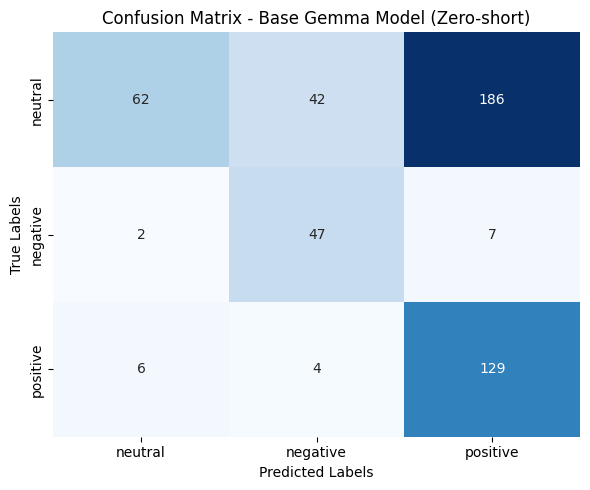

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Compute conufsion matrix
cm = confusion_matrix(filtered_true, filtered_preds, labels = labels)

# Create heatmap
plt.figure(figsize = (6,5))
sns.heatmap(cm, annot= True,
            fmt="d",
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            cbar = False
            )
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Base Gemma Model (Zero-short)")
plt.tight_layout()
plt.show()


## Fine-Tuning Open Source Model (PEFT/LORA & SEFTTrainer)  
- LoRA is a technique used in LLMs to reduce the computational cost and memory requirements by adapting only a small subset of the model parameters during fine-tuning.  
- Ex. if $\Delta W$ has 10,000 rows and 200,000,000 parameters. If we choose A and B with r = 8, then A has 10,000 rows and 8 columns, and B has 8 rows and 20,000 columns. That's `10,000*8 + 8*20,000` parameters, which is `830x` less than 200,000,000.

### LoRA Paper  
- LORA Paper: https://arxiv.org/abs/2106.09685  

Now for the exciting part! We'll fine tune our base open-source model using the training data we prepared. We'll use **PEFT (LoRA)** to do this efficiently without needing massive amount of VRAM. `SEFTTrainer` from the `trl` library simplifies the traiing loop.  
**Key Concepts:**
- **PEFT (Parameter-Efficient-Fine-Tuning):** Instead of updating all the billions of parameters in the LLm, PEFT methods like LoRA add small, trainable "adapter" layers. We only train these adapters, which is much faster and uses far less memory.
- `**SFTTrainer**`: A convenient Hugging Face trainer class designed for Supervised Fine-tuning tasks where the input is formatted text (like out prompts) and the model learns to generate the desired output (label).  

**Steps**:  
1. **Load Base Model (again, if needed):** Ensure the base model and tokenizer are loaded, this time prepared for training (using `prepare_model_for_kbit_training`).
2. **Configure LoRA**: Define `LoraConfig` specifying which parts of the model to adapt and the LoRA parameters (like rank `r`, `alpha`).
3. **Configure Training Arguments**: Set hyperparameters like learning rate, batch size, number of epochs, output directory using `TrainingArguments`.
4. **Initialize `SFTTrainer`**: Pass the model, tokenizer, datasets, LoRA config, and training arguments.
5. **Start Training**: Call `trainer.train()`.
6. **Save Adapter**: Sae the trained LoRA adapter weights using `trainer.save_model()`.
7. **Load Fine-tuned Model**: Load the base model plus the trained LoRA adapter weights for evaluation.

In [25]:
# A Quick reminder to our formatted traiing dataset in an SFT-Trainer format.
# The `SFTTrainer` works by training the model on a Sausal Language Modeling objective.
# This means the model learns to predict the next token in a sequence.
# By providing the entire formatted text (including the `assistant`'s response, i.e., the correct label),
# the model learns that after seeing the system prompt and the user sentences.
# the most likely next token sequence is the correct lable (e.g., "negative, followed by `<|im_end|>`).
# It learns the mapping from input (prompt + sentence) to output (label) imlicitly through next-token prediction on this structured text.

print("\n--- Preparing Model and Config for PEFT/LoRA Fine-Tuning ---")

# --- Prepare model for k-bit training (important for quantized models) ---
base_os_model.gradient_checkpointing_enable()
prepared_model = prepare_model_for_kbit_training(base_os_model)
print("Model prepared for k-bit training.")

print(prepared_model)

# --- LoRA Configuration ---
# Target modules often include query/key/value layers in attention blocks
# This depends on the model architecture (use print(prepared_model) to inspect layers)
# For Qwen-based models, common targets might be 'q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'
# Let's start with a reasonable default set.
lora_config = LoraConfig(
    r = 16,         # LoRA Rank (dimension of adapter metrices). Higher rank = more parameters, potentially better fit but slower. 8, 16, 32 are common
    lora_alpha = 32, # Scaling factor for LoRA weights (often 2*r)
    target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj'],   # Modules to apply LoRA to
    lora_dropout = 0.05,     # Dropout probability for LoRA Layers
    bias = 'none',          # Usually set to 'none
    task_type = "CAUSAL_LM"   # Task type for sequence generation.
)

print("LoRA Config Created")

# --- Apply PEFT to the model ---
# This adds the smallLoRA layers into the big model. During fine-tuning, only these are updated - saving a lot of compute and memory.
peft_model = get_peft_model(prepared_model, lora_config)


# This percentage (often <1%) is small because LoRA only introduces and trains the parameters within the small adpater layers ('q_proj', 'k_proj', etc. in our config)
# It does not train the origional billioins of parameters in the base model (which remain frozen)
# Training far fewer parameters requires significantly less GPU memory (VRAM), making it feasible to fine-tune large models on hardware like colab's T4 GPU.
# It's also much faster than full fine-tuning.
print("PEFT model created.")
peft_model.print_trainable_parameters()     # See how few parameters we're actually training.





--- Preparing Model and Config for PEFT/LoRA Fine-Tuning ---
Model prepared for k-bit training.
Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 1152, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear4bit(in_features=1152, out_features=1024, bias=False)
          (k_proj): Linear4bit(in_features=1152, out_features=256, bias=False)
          (v_proj): Linear4bit(in_features=1152, out_features=256, bias=False)
          (o_proj): Linear4bit(in_features=1024, out_features=1152, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear4bit(in_features=1152, out_features=6912, bias=False)
          (up_proj): Linear4bit(in_features=1152, out_features=6912, bias=False)
          (down_proj): Linear4bit(in_features=6912

In [41]:
import os
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    BitsAndBytesConfig,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer

# --- Training Arguments ---
# These hyperparameters control the training process. Adjust based on performance and time constraints.
output_dir = "./sentiment_finetuned_adapter"  # Directory to save adapter weights

training_args = TrainingArguments(
    output_dir = output_dir,
    per_device_train_batch_size = 4,  # Adjust based on GPU memory (2, 4, 8 typical for Colab)
    gradient_accumulation_steps = 2,  # Effective batch size = batch_size * grad_accum_steps
    learning_rate = 2e-4,  # Common starting point for LoRA
    num_train_epochs = 1,  # Start with 1 epoch for faster iteration/testing. Increase to 2-3 if needed.
    logging_steps = 25,  # Log training loss every N steps
    save_strategy = "epoch",  # Save adapter checkpoint at the end of each epoch
    # optim="paged_adamw_8bit", # Use paged optimizer for memory efficiency (requires bitsandbytes >= 0.41.0) - try if memory issues occur
    fp16=not torch.cuda.is_bf16_supported(),  # Use fp16 if bf16 not supported
    bf16 = torch.cuda.is_bf16_supported(),  # Use bf16 if supported (preferred)
    max_grad_norm = 0.3,  # Gradient clipping
    warmup_ratio = 0.03,  # Learning rate warmup
    lr_scheduler_type = "constant",  # Or "linear", "cosine"
    report_to = "none",  # Disable wandb/tensorboard reporting for simplicity
)
print("Training Arguments set.")

# --- Initialize SFTTrainer ---
data_collator = DataCollatorForLanguageModeling(tokenizer=base_os_tokenizer, mlm=False)

trainer = SFTTrainer(
    model = peft_model,  # The PEFT model
    args = training_args,  # Training arguments
    train_dataset = sft_train_dataset,  # Formatted training data
    data_collator = data_collator,
    processing_class = base_os_tokenizer # Explicitly set processing_class to the tokenizer instance
)
print("SFTTrainer initialized.")

# --- Start Fine-tuning ---
print("\n--- Starting Fine-tuning... ---")
try:
    training_results = trainer.train()
    print("--- Fine-tuning Complete! ---")
    print(training_results)

    # --- Save the LoRA Adapter ---
    print(f"Saving LoRA adapter model to {output_dir}...")
    trainer.save_model(output_dir)  # Saves only the adapter weights
    # Also save the tokenizer for consistency
    base_os_tokenizer.save_pretrained(output_dir)
    print("Adapter and tokenizer saved.")

    # --- Clean up memory (important before loading for evaluation) ---
    del trainer
    del peft_model  # Delete the model used for training
    # del prepared_model # Optional
    # del base_os_model # Keep the original base model if needed later, or delete
    torch.cuda.empty_cache()
    import gc

    gc.collect()
    print("Cleaned up training objects from memory.")

    fine_tuning_successful = True

except Exception as e:
    print(f"Error during fine-tuning: {e}")
    fine_tuning_successful = False


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training Arguments set.


/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:964: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  args = SFTConfig(**dict_args)


Adding EOS to train dataset:   0%|          | 0/4361 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4361 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.


SFTTrainer initialized.

--- Starting Fine-tuning... ---


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
25,3.773932
50,2.129207
75,1.876821
100,1.735757
125,1.742792
150,1.679276
175,1.663910
200,1.645396
225,1.658149
250,1.641736


--- Fine-tuning Complete! ---
TrainOutput(global_step=546, training_loss=1.7714158781282194, metrics={'train_runtime': 1348.6981, 'train_samples_per_second': 3.233, 'train_steps_per_second': 0.405, 'total_flos': 1539363477583872.0, 'train_loss': 1.7714158781282194, 'entropy': 1.5230322640116623, 'mean_token_accuracy': 0.7077643667779318, 'num_tokens': 294220.0, 'epoch': 1.0})
Saving LoRA adapter model to ./sentiment_finetuned_adapter...
Adapter and tokenizer saved.
Cleaned up training objects from memory.


## Evaluate the Fine-Tuned Model  
Now, let's evaluate the model we just fine-tuned! We need to laod the base model again but *merge* it with the traiend LoRA adapter weights. Then, we run the same zero-shot classification evaluation process as in the previous steps on the test set.  
**Steps:**
1. **Load the Fine-tuned Model:**
    - Load the base model configuration (quantized)
    - Load the base model weights.
    - Load the PEFT adapter weights from the directory where we saved them (`output_dir`)
    - Combine the base model and the adapter.
2. **Run Inference:** use the same zero-shot classification function (`classify_zero_shot_os`) and prompt template on the test set, but pass the *fine-tuned PEFT model*.
3. **Calculate Metrics:** Compute accuracy and the classification report.
4. **Compare:** Compare these results directly with the baeline zero-shot resutls from previous tasks.


In [43]:
tuned_os_predictions = []

adapter_path = "./sentiment_finetuned_adapter"
print(f"\n--- Loading Fine-tuned Open Source Model from {adapter_path}")

# --- Load Tokenizer (from saved adapter dir) ---
tuned_os_tokenizer = AutoTokenizer.from_pretrained(adapter_path, trust_remote_code = True)

# --- Ld base Model (Quantized) ---
# It's often cleaner to reload the bae model before applying the adapter
quantization_config = BitsAndBytesConfig(bload_in_4bit=True)

base_model_reload = AutoModelForCausalLM.from_pretrained(
    os_model_id,        # The origional base model ID
    quantization_config = quantization_config,
    device_map = 'auto',
    trust_remote_code = True,
)

# set pad token ID on the reloaded model config if needed
if tuned_os_tokenizer.pad_token_id is not None:
    base_model_reload.config.pad_token_id = tuned_os_tokenizer.pad_token_id

    # --- Load PEFT Adapter and Merge (or use directly) ---
    # Load PeftModel directly (uses base + adapter without merging)
from peft import PeftModel

tuned_os_model = PeftModel.from_pretrained(base_model_reload, adapter_path)
print("Loaded PEFT model (base + adapter).")

# Ensure model is in evaluation mode.
tuned_os_model.eval()
print("Fine-tuned OS model loaded usccessfully")

# --- Evaluate on Test Set ---

# Assuming true_labels list was populated in previos steps
if 'true_labels' not in locals() or not true_labels:
    print("Warning: true_labels not found from previous steps. Re-extracting.")
    true_labels = [ex['sentiment'] for ex in test_dataset]

for example in tqdm(test_dataset):  # use tqdm for progress bar
    sentence = example['text']
    # Use the SAME zero-shot function, but pass the TUNED model
    predicted_label = classify_zero_shot_os_gemma(sentence, tuned_os_model, tuned_os_tokenizer)
    tuned_os_predictions.append(predicted_label)

print("\n-- Fine-Tuned Open Source Model: Evaluation Results ---")
valid_indices_tuned = [i for i,p in enumerate(tuned_os_predictions) if p not in ["Error", "Unknown"]]
filtered_preds_tuned = [tuned_os_predictions[i] for i in valid_indices_tuned]

# Ensure we use the same true labels corresponding to the test set order
filtered_true_tuned = [
    true_labels[i] for i in valid_indices_tuned
]

accuracy_tuned = accuracy_score(filtered_true_tuned, filtered_preds_tuned)
report_tuned = classification_report(
    filtered_true_tuned, filtered_preds_tuned, labels = labels, zero_division = 0
)

print(f"Accuracy: {accuracy_tuned: .4f}")
print("\nClassification Report: ")
print(report_tuned)

# --- Compare with Base OS Model ---
print("\n--- Comparision with Base OS Model ---")

print(f"\nBase OS Accuracy: {accuracy:.4f}")
print(f"\nFine-Tuned OS Accuracy: {accuracy_tuned:.4f}")
improvement = accuracy_tuned - accuracy
print(f"\nImprovement: {improvement:+.4f}")


--- Loading Fine-tuned Open Source Model from ./sentiment_finetuned_adapter


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Loaded PEFT model (base + adapter).
Fine-tuned OS model loaded usccessfully


  0%|          | 0/485 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Predicted label: positive
Predicted label: negative
Predicted label: neutral
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: neutral
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: neutral
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: neutral
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: neutral
Predicted label: positive
Predicted label: positive
Predicted label: neutral
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: positive
Predicted label: negative
Predicted label: n